In [1]:
import torch
from torchvision import models

weights = models.ResNet18_Weights.DEFAULT
# Load ResNet18 with default weights
model = models.resnet18(weights=weights)

# Set the model to evaluation mode
model.eval()

# Get the preprocessing transforms associated with the weights
preprocess = weights.transforms()
print(f"ResNet18 model loaded with default weights: {weights} and set to evaluation mode.")

ResNet18 model loaded with default weights: ResNet18_Weights.IMAGENET1K_V1 and set to evaluation mode.


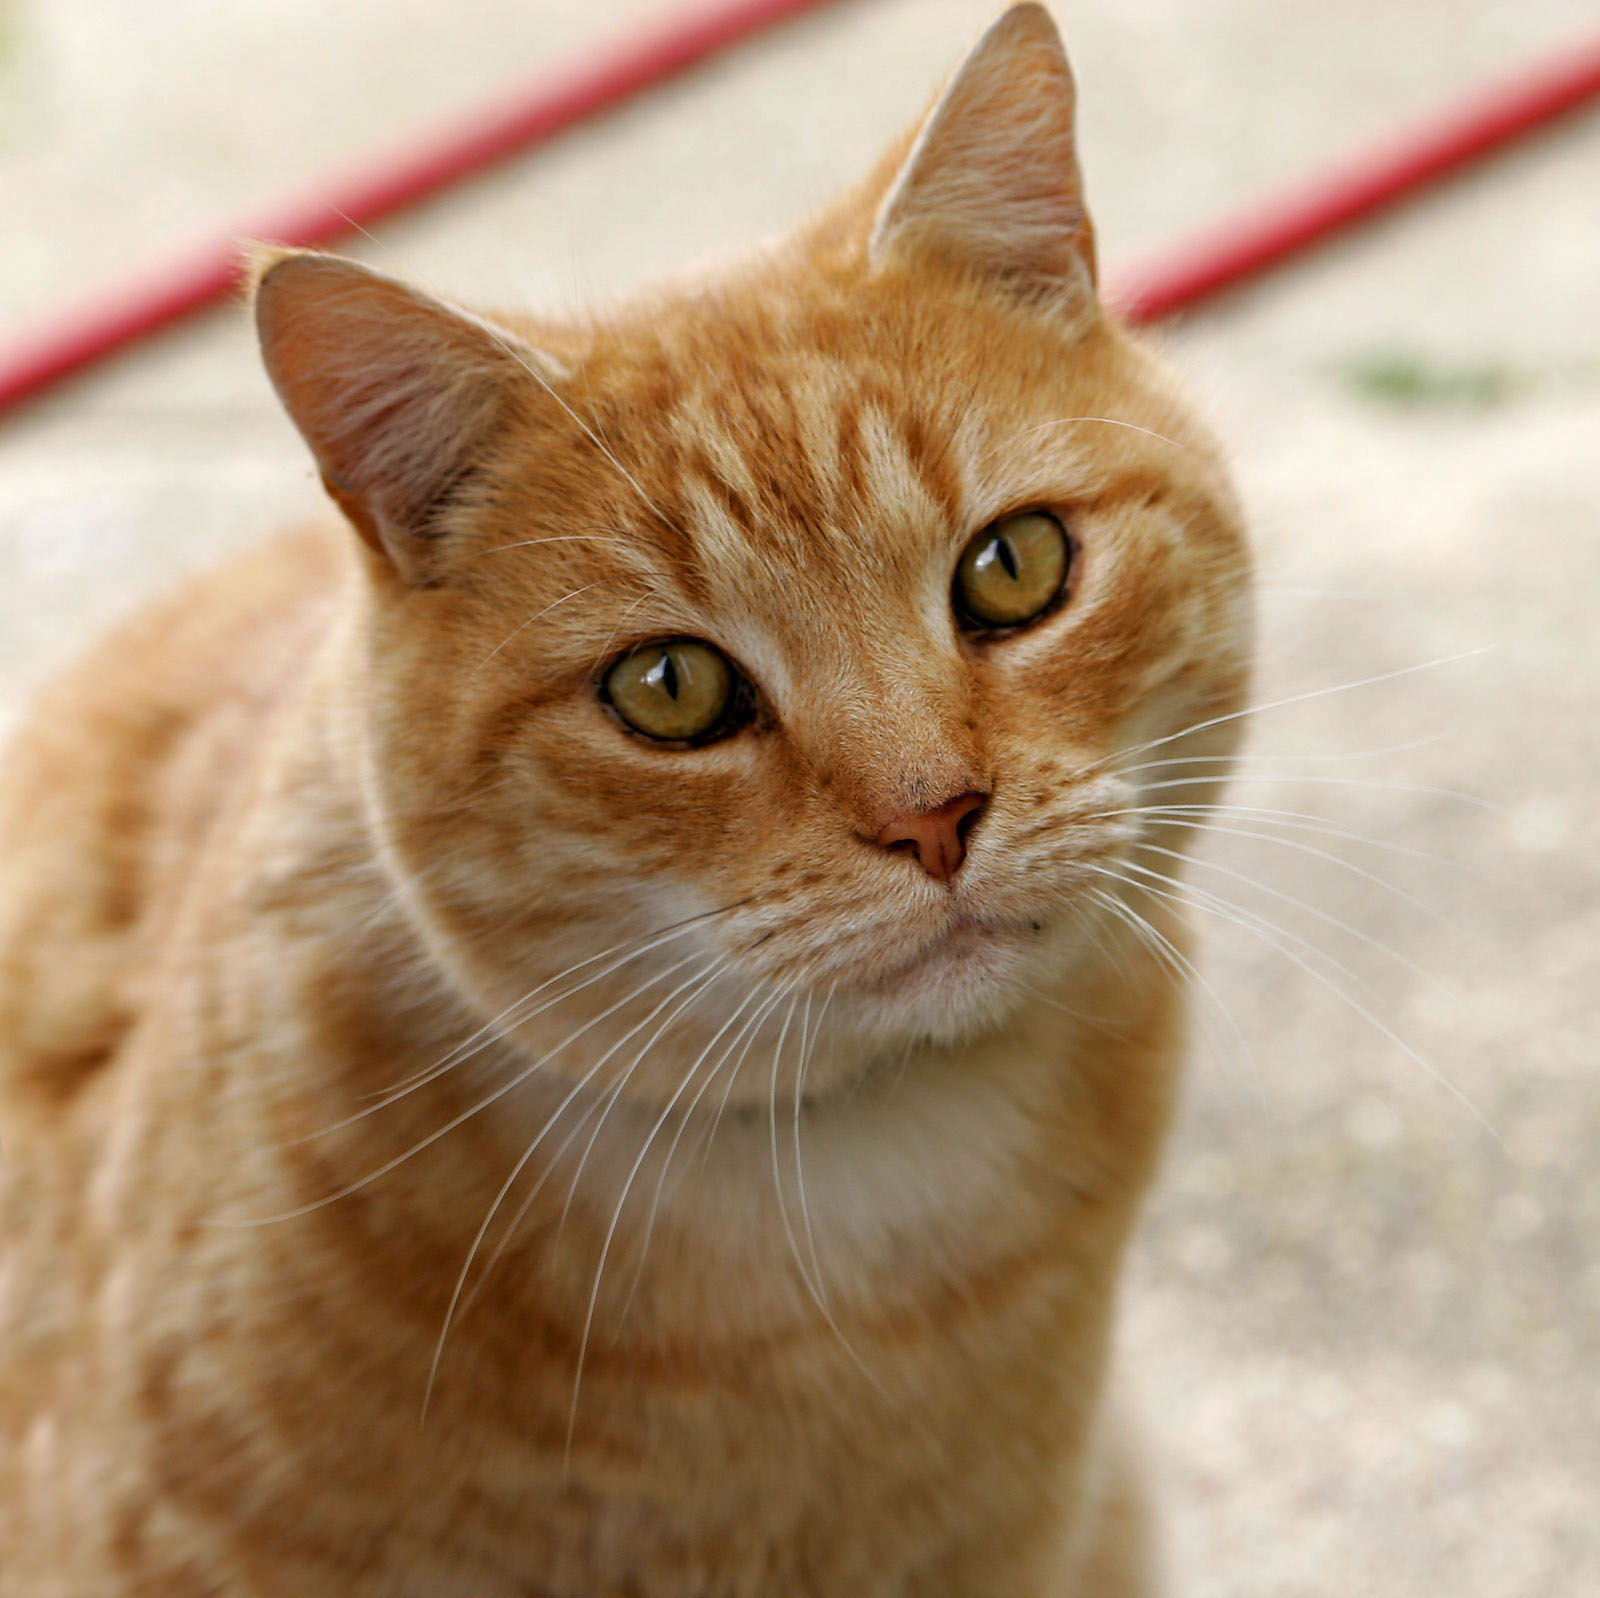

In [2]:
from pathlib import Path
from IPython.display import display
from urllib.request import urlretrieve
from PIL import Image

image_path = Path("Cat03.jpg")

if not image_path.exists():
    urlretrieve("https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg", image_path)
    print(f"Image downloaded to: {image_path}")
    
image = Image.open(image_path).convert("RGB")

display(image)

# Preprocess the image and create a batch siz of 1
input_tensor = preprocess(image).unsqueeze(0)

In [3]:
import torch
from torchvision import models
from pathlib import Path
from IPython.display import display
from urllib.request import urlretrieve
from PIL import Image

# Prepare to transform the image for neural networks
preprocess = weights.transforms()

# Apply the transforms to the PIL image
# This resizes, center-crops, converts to a tensor, and normalizes
input_tensor = preprocess(image)

# Add a batch dimension: [3, 224, 224] -> [1, 3, 224, 224]
input_batch = input_tensor.unsqueeze(0)

print(f"Tensor shape after preprocessing: {input_tensor.shape}")
print(f"Batch shape sent to the model: {input_batch.shape}")

Tensor shape after preprocessing: torch.Size([3, 224, 224])
Batch shape sent to the model: torch.Size([1, 3, 224, 224])


In [4]:
import torch
from torchvision import models
from pathlib import Path
from IPython.display import display
from urllib.request import urlretrieve
from PIL import Image

# Pass the prepared image through the model without calculating gradients
with torch.no_grad():
    output = model(input_batch)

print(f"Output shape: {output.shape}")

Output shape: torch.Size([1, 1000])


In [6]:
import torch
from torchvision import models
from pathlib import Path
from IPython.display import display
from urllib.request import urlretrieve
from PIL import Image

# Convert logits to probabilities with softmax
probabilities = torch.nn.functional.softmax(output[0], dim=0)

# Get the top 3 probabilities and their class indices
top3_prob, top3_idx = torch.topk(probabilities, 3)

# Get the category names tied to the default weights
categories = weights.meta["categories"]

# Display the results
print("Top 3 predictions:")
for i in range(3):
    label = categories[top3_idx[i].item()]
    confidence = top3_prob[i].item() * 100
    print(f"{i + 1}. {label}: {confidence:.2f}%")

Top 3 predictions:
1. Egyptian cat: 41.07%
2. tiger cat: 39.43%
3. tabby: 15.42%


## Reflection Questions

**1. What was shown in your image?**
The image is a close-up photograph of a cat looking toward the camera. The notebook opens `Cat03.jpg`; if that file is not present in the working directory, it downloads the image from Wikimedia Commons first.

**2. What were the model's top three predictions?**
The pretrained ResNet18 model returned scores for 1,000 ImageNet classes. After converting the output scores to probabilities with softmax, the three highest-ranked classes were:
1. Egyptian cat: 41.07%
2. tiger cat: 39.43%
3. tabby: 15.42%

**3. Was the highest prediction correct? Explain your answer.**
Partly. The image does show a cat, and the model's top three predictions are all cat classes. Its highest-ranked label was "Egyptian cat" at 41.07%, but the image alone does not establish the cat's specific breed or type. The percentages are softmax scores relative to the model's 1,000 ImageNet classes; they should not be treated as guaranteed or calibrated certainty. The top three scores total 95.92%, with the remaining score spread over the other classes.

**4. Why might the model produce an incorrect prediction?**
ResNet18 learned patterns from its training data, so it can confuse visually similar classes or choose the closest available ImageNet label even when that label is not exact. The notebook applies the weights' standard preprocessing, including resizing and center-cropping the image to 224×224 pixels; this can remove useful details. Image quality, lighting, viewing angle, background, and limitations or biases in the training data can also affect predictions.

**5. Is this Artificial Intelligence, Machine Learning, or Deep Learning?**
It is all three. Artificial Intelligence (AI) is the broad field of systems that perform tasks associated with human intelligence. Machine Learning (ML) is a part of AI in which a system learns patterns from data. Deep Learning is a part of ML that uses neural networks with many layers. This notebook uses a pretrained ResNet18 convolutional neural network, so it demonstrates deep learning, which is a form of machine learning and AI.

**6. What is one real-world application of image classification?**
Image classification can help sort or flag medical images, such as X-rays, for a clinician to review. It can support review, but should not replace professional judgment.

**7. What is one limitation or concern?**
A classifier may be wrong or may perform unevenly if its training data does not represent the images it encounters. The output here is a ranking among ImageNet's 1,000 classes, not an explanation or a guarantee. In high-stakes settings, errors can cause harm, so predictions need appropriate human review.